Implement a **Neural Network model** using fully connected layers, non-linear activation, skip connections, dropout, etc. (Note that you are only allowed to use MLP blocks and must not use CNNs, Transformers, or other advanced deep learning architectures) (Can train on a 10GB GPU ).

Data: [MNIST datasets](https://www.kaggle.com/competitions/digit-recognizer/data)

# Data downloading

In [1]:
data_url = "https://raw.githubusercontent.com/ThaiLearnCoding/NLP-Labs/main/Lab%208%20-%20Neural%20Network/data/"

train_url = data_url + "train.csv.zip"
test_url = data_url + "test.csv.zip"
sample_url = data_url + "sample_submission.csv"

In [2]:
!wget $train_url
!wget $test_url
!wget $sample_url

--2026-04-01 05:46:25--  https://raw.githubusercontent.com/ThaiLearnCoding/NLP-Labs/main/Lab%208%20-%20Neural%20Network/data/train.csv.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9606023 (9.2M) [application/zip]
Saving to: ‘train.csv.zip’

train.csv.zip       100%[===================>]   9.16M  44.5MB/s    in 0.2s    

2026-04-01 05:46:26 (44.5 MB/s) - ‘train.csv.zip’ saved [9606023/9606023]

--2026-04-01 05:46:26--  https://raw.githubusercontent.com/ThaiLearnCoding/NLP-Labs/main/Lab%208%20-%20Neural%20Network/data/test.csv.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
H

In [3]:
!unzip train.csv.zip
!unzip test.csv.zip

Archive:  train.csv.zip
  inflating: train.csv               
Archive:  test.csv.zip
  inflating: test.csv                


In [4]:
!rm -f $train_url
!rm -f $test_url

# Preprocessing

In [5]:
import pandas as pd

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_df = pd.read_csv("sample_submission.csv")

In [6]:
train_df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
train_df['pixel500'].value_counts()

,count
pixel500,
0,40311
253,117
252,66
254,32
251,23
...,...
181,1
232,1
100,1


In [8]:
sample_df

,ImageId,Label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
27995,27996,0
27996,27997,0
27997,27998,0
27998,27999,0


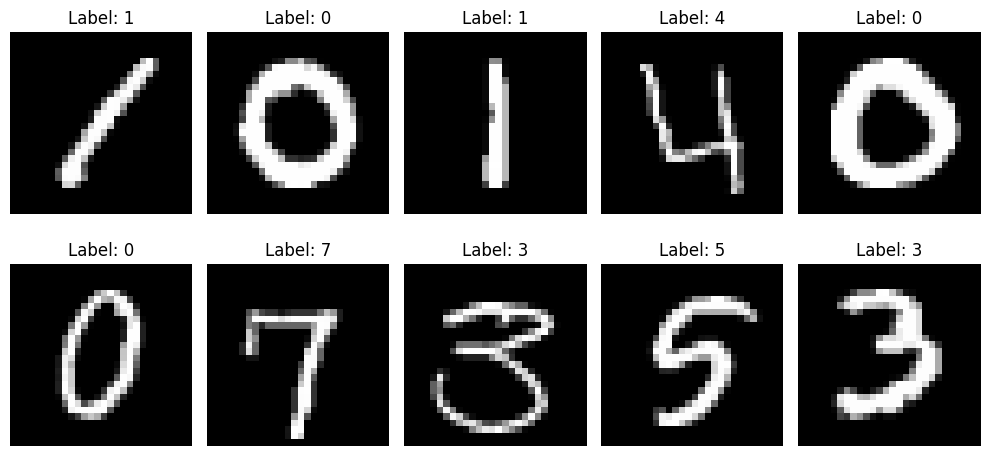

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Separate features (pixels) and labels
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

# Reshape pixel data into images (28x28)
X_train_images = X_train.reshape(-1, 28, 28)

# Display the first 10 images with their labels
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(X_train_images[i], cmap='gray')
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Model training

### Data Preparation for PyTorch

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Assuming train_df and test_df are already loaded from previous cells

# Separate features (X) and labels (y) from training data
X_train_np = train_df.drop('label', axis=1).values.astype(np.float32)
y_train_np = train_df['label'].values.astype(np.int64)
X_test_np = test_df.values.astype(np.float32)

# Normalize pixel values to be between 0 and 1
X_train_normalized_np = X_train_np / 255.0
X_test_normalized_np = X_test_np / 255.0

# Split training data into training and validation sets
X_train_split_np, X_val_split_np, y_train_split_np, y_val_split_np = train_test_split(
    X_train_normalized_np, y_train_np, test_size=0.2, random_state=42
)

# Convert numpy arrays to PyTorch Tensors
X_train_tensor = torch.from_numpy(X_train_split_np)
y_train_tensor = torch.from_numpy(y_train_split_np)
X_val_tensor = torch.from_numpy(X_val_split_np)
y_val_tensor = torch.from_numpy(y_val_split_np)
X_test_tensor = torch.from_numpy(X_test_normalized_np)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor)

# Create DataLoaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"X_val_tensor shape: {X_val_tensor.shape}")
print(f"y_val_tensor shape: {y_val_tensor.shape}")
print(f"X_test_tensor shape: {X_test_tensor.shape}")

X_train_tensor shape: torch.Size([33600, 784])
y_train_tensor shape: torch.Size([33600])
X_val_tensor shape: torch.Size([8400, 784])
y_val_tensor shape: torch.Size([8400])
X_test_tensor shape: torch.Size([28000, 784])


### PyTorch Model Definition (MLP with Skip Connections and Dropout)

In [11]:
class MLPWithSkipConnections(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLPWithSkipConnections, self).__init__()
        self.fc1 = nn.Linear(input_size, 512)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, 256)
        self.dropout2 = nn.Dropout(0.3)
        self.skip_fc = nn.Linear(512, 256) # Linear layer for skip connection to match dimensions
        self.fc3 = nn.Linear(256, 128)
        self.dropout3 = nn.Dropout(0.2)
        self.output_layer = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        # First Block (Linear -> ReLU -> Dropout)
        x_initial = x # Store initial input for potential skip connection if needed
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)

        # Store output of first block for skip connection
        skip_connection_1 = x

        # Second Block (Linear -> ReLU -> Dropout)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)

        # Skip Connection: Add output of first block (after linear transformation to match dims) to second block's output
        residual = self.skip_fc(skip_connection_1)
        x = x + residual # Skip connection (addition)
        x = self.relu(x) # Activation after addition

        # Third Block (Linear -> ReLU -> Dropout)
        x = self.relu(self.fc3(x))
        x = self.dropout3(x)

        # Output layer
        out = self.output_layer(x)
        return out

# Define input size and number of classes
input_size = X_train_tensor.shape[1]
num_classes = len(torch.unique(y_train_tensor)) # Number of unique labels

# Build the model
model_pytorch = MLPWithSkipConnections(input_size, num_classes)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_pytorch.to(device)

print(model_pytorch)

MLPWithSkipConnections(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (skip_fc): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


### Compile and Train the PyTorch Model

In [12]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pytorch.parameters(), lr=0.001)

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50):
    best_val_accuracy = 0.0
    patience = 5
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct_train / total_train

        # Validation phase
        model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_accuracy = correct_val / total_val

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

        # Early stopping
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_model.pth') # Save the best model
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print('Early stopping!')
                break

    # Load the best model weights
    model.load_state_dict(torch.load('best_model.pth'))
    return model

# Train the model
model_pytorch_trained = train_model(model_pytorch, train_loader, val_loader, criterion, optimizer)

# Evaluate the model on the validation set after training
model_pytorch_trained.eval()
val_loss_final = 0.0
correct_val_final = 0
total_val_final = 0
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_pytorch_trained(inputs)
        loss = criterion(outputs, labels)

        val_loss_final += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_val_final += labels.size(0)
        correct_val_final += (predicted == labels).sum().item()

val_loss_final /= len(val_loader.dataset)
val_accuracy_final = correct_val_final / total_val_final

print(f"Final Validation Loss: {val_loss_final:.4f}")
print(f"Final Validation Accuracy: {val_accuracy_final:.4f}")

Epoch 1/50, Train Loss: 0.4416, Train Acc: 0.8618, Val Loss: 0.1808, Val Acc: 0.9460
Epoch 2/50, Train Loss: 0.1642, Train Acc: 0.9506, Val Loss: 0.1296, Val Acc: 0.9600
Epoch 3/50, Train Loss: 0.1180, Train Acc: 0.9649, Val Loss: 0.1025, Val Acc: 0.9679
Epoch 4/50, Train Loss: 0.0922, Train Acc: 0.9716, Val Loss: 0.1033, Val Acc: 0.9695
Epoch 5/50, Train Loss: 0.0793, Train Acc: 0.9756, Val Loss: 0.0940, Val Acc: 0.9730
Epoch 6/50, Train Loss: 0.0656, Train Acc: 0.9790, Val Loss: 0.0916, Val Acc: 0.9729
Epoch 7/50, Train Loss: 0.0546, Train Acc: 0.9831, Val Loss: 0.0885, Val Acc: 0.9745
Epoch 8/50, Train Loss: 0.0551, Train Acc: 0.9826, Val Loss: 0.0824, Val Acc: 0.9765
Epoch 9/50, Train Loss: 0.0456, Train Acc: 0.9857, Val Loss: 0.0902, Val Acc: 0.9750
Epoch 10/50, Train Loss: 0.0425, Train Acc: 0.9861, Val Loss: 0.0960, Val Acc: 0.9756
Epoch 11/50, Train Loss: 0.0388, Train Acc: 0.9871, Val Loss: 0.0915, Val Acc: 0.9756
Epoch 12/50, Train Loss: 0.0325, Train Acc: 0.9893, Val Loss: 0

### Visualize Error Cases

Total error cases found: 191


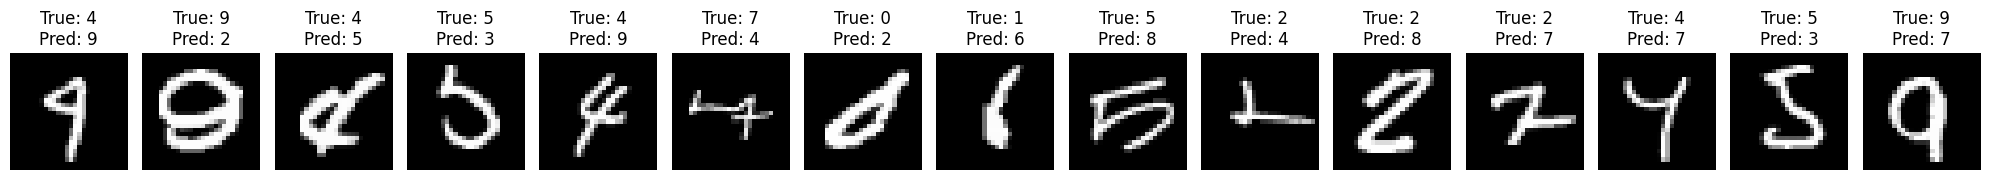

In [13]:
import matplotlib.pyplot as plt

def plot_error_cases(model, data_loader, true_labels_tensor, num_images=10):
    model.eval() # Set model to evaluation mode
    all_predictions = []
    all_true_labels = []
    all_images = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())
            all_images.extend(inputs.cpu().numpy())

    all_predictions = np.array(all_predictions)
    all_true_labels = np.array(all_true_labels)
    all_images = np.array(all_images)

    # Find indices where predictions are incorrect
    error_indices = np.where(all_predictions != all_true_labels)[0]
    print(f"Total error cases found: {len(error_indices)}")

    # Randomly select a subset of error indices to display
    if len(error_indices) > num_images:
        display_indices = np.random.choice(error_indices, num_images, replace=False)
    else:
        display_indices = error_indices

    fig, axes = plt.subplots(1, len(display_indices), figsize=(20, 3))
    if len(display_indices) == 0:
        print("No error cases to display.")
        return
    elif len(display_indices) == 1:
        axes = [axes] # Make it iterable for consistency

    for i, idx in enumerate(display_indices):
        image = all_images[idx].reshape(28, 28) # Reshape flat image to 28x28
        true_label = all_true_labels[idx]
        predicted_label = all_predictions[idx]

        axes[i].imshow(image, cmap='gray')
        axes[i].set_title(f"True: {true_label}\nPred: {predicted_label}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to plot error cases from the validation set
# We use val_loader for inputs and true_labels_tensor is not directly used here, but all_true_labels are extracted from val_loader itself.
plot_error_cases(model_pytorch_trained, val_loader, y_val_tensor, num_images=15)

# Generate CSV result file

In [14]:
# Make predictions on the test data
model_pytorch_trained.eval()  # Set the model to evaluation mode
predictions_list = []
with torch.no_grad():
    for inputs in test_loader:
        inputs = inputs[0].to(device) # DataLoaders for single tensor return a tuple
        outputs = model_pytorch_trained(inputs)
        _, predicted = torch.max(outputs.data, 1)
        predictions_list.extend(predicted.cpu().numpy())

# Prepare submission dataframe
submission_df_pytorch = pd.DataFrame({'ImageId': range(1, len(predictions_list) + 1), 'Label': predictions_list})

# Save to CSV
submission_df_pytorch.to_csv('submission_pytorch.csv', index=False)

print("Submission file 'submission_pytorch.csv' created successfully!")

# Display the first few rows of the submission file
display(submission_df_pytorch.head())

Submission file 'submission_pytorch.csv' created successfully!


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


# Image of submission on Kaggle

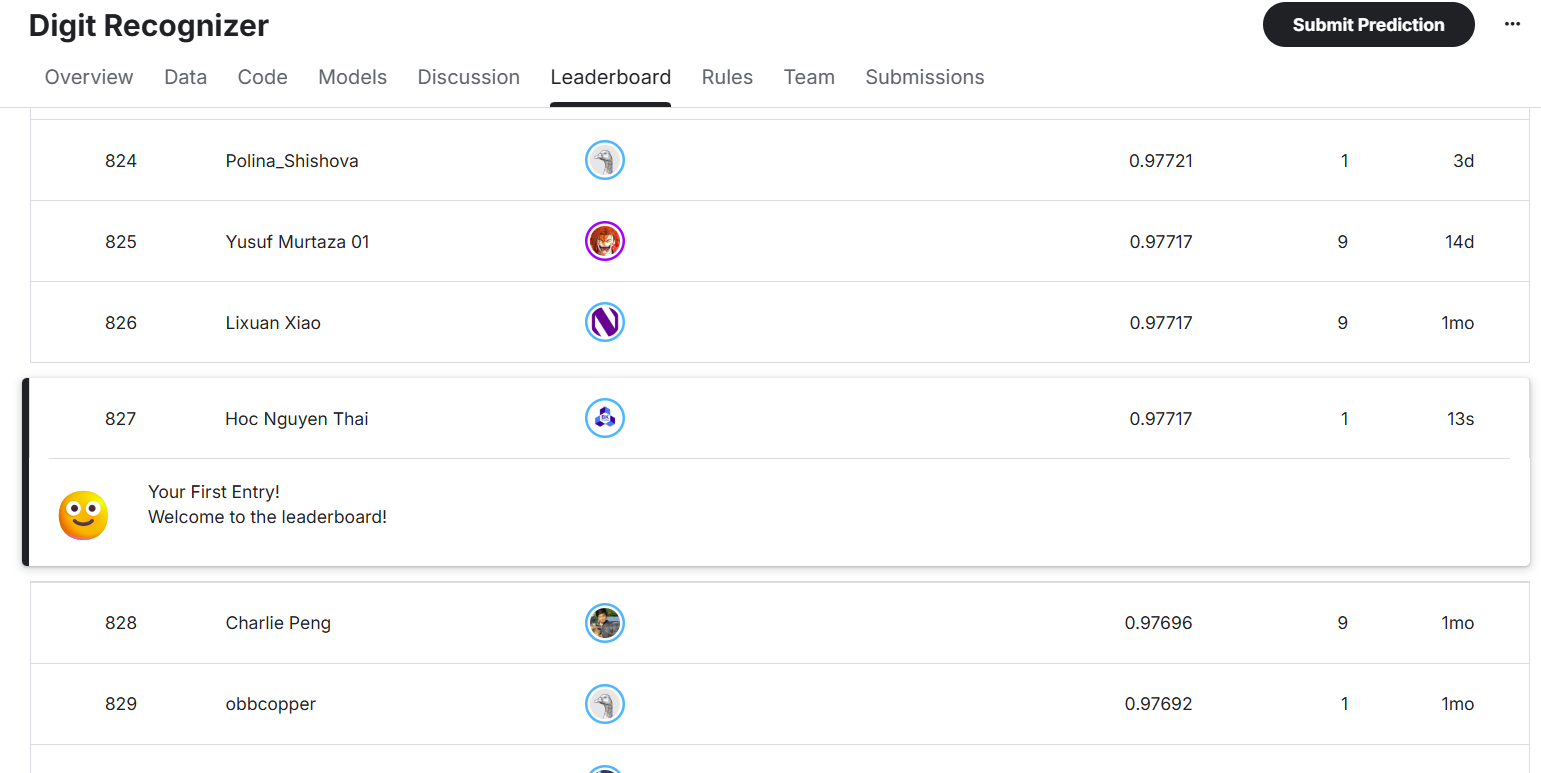